In [11]:
#Imports

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix, root_mean_squared_log_error
import seaborn as sns

In [2]:
trainingData = pd.read_csv("../Calorie_data/train.csv")
testingData = pd.read_csv("../Calorie_data/test.csv")

In [3]:
trainingData.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [4]:
trainingData.isnull().sum()

id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [5]:
#Encode the 'Sex' data
trainingData['Sex'] = pd.get_dummies(trainingData[['Sex']], drop_first = True)

In [6]:
trainingData.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,True,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,False,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,False,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,True,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,False,38,166.0,61.0,25.0,102.0,40.6,146.0


Text(0.5, 1.0, 'Correlation Heatmap')

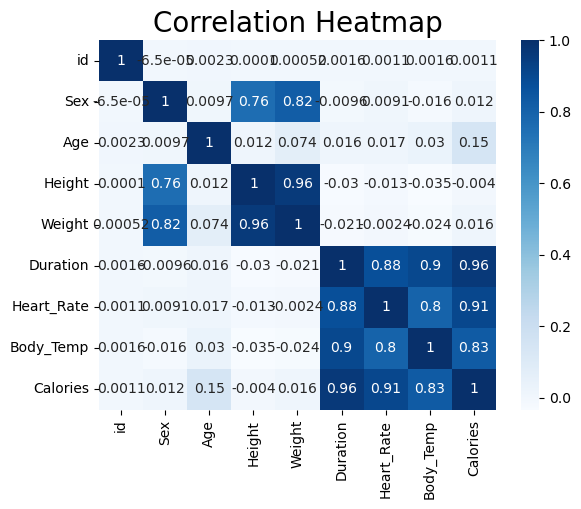

In [12]:
#Correlation for trainingData
heatmap = sns.heatmap(trainingData.corr(), cmap = 'Blues', annot = True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize' : 20})

In [7]:
testingData.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5


In [8]:
testingData.isnull().sum()

id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
dtype: int64

In [65]:
#Seperate the trainingData
Y = ['Calories']
trainY = trainingData[Y]
trainX = trainingData[['Duration','Heart_Rate','Body_Temp']]

In [66]:
#Split the data
X_train, X_test, Y_train, Y_test = train_test_split(trainX,
                                                    trainY,
                                                    test_size = 0.3,
                                                    random_state=42)

Y_train_log = np.log1p(Y_train)

In [67]:
#Linear Regression
initial_model = LinearRegression()

initial_model.fit(X_train,Y_train_log)

preds = initial_model.predict(X_test)
preds = np.exp(preds) - 1
preds = np.round(preds)

mse = mean_squared_error(Y_test, preds)
mae = mean_absolute_error(Y_test, preds)
rmsle = root_mean_squared_log_error(Y_test, preds)

In [68]:
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Log Error: {rmsle}")

Mean Squared Error: 348.2665733333333
Mean Absolute Error: 12.203657777777778
Root Mean Squared Log Error: 0.203341598064539


In [57]:
df = pd.DataFrame(preds, columns = ['Calories'], index = X_test.index)
df

,Calories
404846,205.698283
580313,69.172155
552086,40.345163
370876,107.113254
239330,52.510801
...,...
501261,17.942652
567005,11.328152
181462,142.357045
558015,146.444558


In [59]:
X_test.head()

,Height,Weight,Duration,Heart_Rate,Body_Temp
404846,163.0,61.0,29.0,108.0,40.8
580313,179.0,87.0,13.0,94.0,40.3
552086,186.0,84.0,10.0,89.0,39.9
370876,161.0,58.0,19.0,98.0,40.6
239330,181.0,77.0,9.0,98.0,40.0
